In [1]:
from graph_transformer_long_range_niches.tl import pad_batch
from graph_transformer_long_range_niches._paths import CFG_FILES, RESULTS, FIG_PATH, LEGNINI23
from graph_transformer_long_range_niches.model import LitGNNTransformer
from graph_transformer_long_range_niches.pl import CustomColormap, plot_attention_sender_receiver, plot_attention_sender_receiver, SelfAttentionRelevance, calculate_attention, normalized_attention, normalized_class_attention
from graph_transformer_long_range_niches.pp import prepare_geome_dataset, split_adata
from graph_transformer_long_range_niches.config import load_config

import warnings
warnings.filterwarnings("ignore")

from torch_geometric.loader import DataLoader

from pathlib import Path
import wandb
import torch
import os

## plotting
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import pickle
from scipy.sparse import issparse

# single cell tools
import scanpy as sc
import squidpy as sq
from anndata import AnnData

from sklearn.preprocessing import MinMaxScaler

/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


In [2]:
FOLDER = "legnini23"
GEX_DATA = "legnini23_None_sample_1_44"

In [3]:
def load_model(PATH, model_type = "gnn-transformer", RESULTS = RESULTS, FOLDER = FOLDER):
    model_transformer_ckpt = torch.load(Path(RESULTS, FOLDER, f"{PATH}_{model_type}.ckpt"))
    cfg = model_transformer_ckpt['hyper_parameters']['cfg']
    model_transformer = LitGNNTransformer(model_transformer_ckpt['hyper_parameters']['cfg'])
    model_transformer.load_state_dict(model_transformer_ckpt['state_dict'])
    obs_csv = pd.read_csv(Path(RESULTS, FOLDER, f"{PATH}_obs.csv"))
    obs_csv = obs_csv.rename(columns={'Unnamed: 0': 'obs_names'})
    return model_transformer, cfg, obs_csv

# Evaluation: Legnini et. al, 2023

Legnini, I., Emmenegger, L., Zappulo, A. et al. Spatiotemporal, optogenetic control of gene expression in organoids. Nat Methods 20, 1544–1552 (2023). https://doi.org/10.1038/s41592-023-01986-w

## Load the model checkpoint and data

In [4]:
model_transformer_gex, cfg_gex, obs_gex = load_model(GEX_DATA, model_type = "gnn-transformer")

num features: 88


In [5]:
adata = sc.read_h5ad(Path(LEGNINI23))
adata

AnnData object with n_obs × n_vars = 43762 × 88
    obs: 'Cell', 'Area', 'x', 'y', 'sample', 'condition', 'organoid', 'obs_names'
    var: 'gene_ids', 'feature_types'
    obsm: 'spatial'
    layers: 'log1p_norm', 'raw'

In [7]:
adata.obs['split'] = np.array(obs_gex['split'].values)

In [13]:
# Creating a DataFrame from 'split', 'fov', and 'condition'
df = adata.obs[['split', 'sample', 'condition']]
value_counts = pd.DataFrame(df.values, columns=df.columns).value_counts()
print(value_counts)

split  sample       condition
train  slide1_D2-2  SHH          4318
       slide1_D2-3  SHH          3621
val    slide1_C2-2  SHH          3510
train  slide4_B2-1  SHH          3345
       slide1_B2-1  SHH          3299
val    slide1_A2-1  SHH          3023
train  slide1_C2-1  Ctrl         2870
       slide4_A2-1  SHH          2630
       slide4_A2-2  SHH          2506
val    slide1_B2-3  SHH          2241
test   slide4_A2-3  Ctrl         1984
val    slide1_C2-5  Ctrl         1958
test   slide4_B2-2  SHH          1779
train  slide1_B2-2  Ctrl         1701
       slide1_A2-2  SHH          1694
       slide4_B2-3  Ctrl         1643
       slide1_C2-3  Ctrl         1640
Name: count, dtype: int64


Q: Is the only covariate the condition or are the sample slices also different in other aspects???

## Inference 

In [8]:
sub_adata_ctrl, attention_matrix_dict_ctrl, trans_in_dict_ctrl, trans_out_dict_ctrl = calculate_attention(adata, cfg_gex, model_transformer_gex, obs_col = 'sample', class_name = 'slide4_A2-3', library_key=None)
sub_adata_shh, attention_matrix_dict_shh, trans_in_dict_shh, trans_out_dict_shh = calculate_attention(adata, cfg_gex, model_transformer_gex, obs_col = 'sample', class_name = 'slide4_B2-2', library_key=None)

call new
call new
call new
test
call new
DataBatch(x=[1984, 88], edge_index=[2, 4], obs_names=[1984], batch=[1984], ptr=[2]) None
Category mask:  torch.Size([1985, 1, 128])
1985
Layer 1 attention gradient shape: torch.Size([4, 1985, 1985])
Layer 1 attention output weights shape: torch.Size([4, 1985, 1985])
Average attention map shape: torch.Size([1985, 1985])
I:  tensor([[1., 0., 0.,  ..., 0., 0., 0.],
        [0., 1., 0.,  ..., 0., 0., 0.],
        [0., 0., 1.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 1., 0., 0.],
        [0., 0., 0.,  ..., 0., 1., 0.],
        [0., 0., 0.,  ..., 0., 0., 1.]])
Layer 2 attention gradient shape: torch.Size([4, 1985, 1985])
Layer 2 attention output weights shape: torch.Size([4, 1985, 1985])
Average attention map shape: torch.Size([1985, 1985])
I:  tensor([[1.0000e+00, 4.2300e-07, 5.7595e-07,  ..., 4.8751e-07, 1.0541e-06,
         1.7230e-07],
        [3.8841e-12, 1.0000e+00, 0.0000e+00,  ..., 1.4994e-11, 4.2690e-11,
         1.1490e-10]

### UMAP DGE based inference

In [50]:
def umap_embeddings(embedding_gnn, 
                    embedding_trans, 
                    leiden_res: float = 0.1):
    """

    
    Input:
    ------
        embedding_gnn: numpy.array [N, E_gnn]
        embedding_trans: numpy.array [N, E_trans]

    Return:
    -------
        leiden_gnn: numpy.array [N]
            Leiden cluster assignments for each cell based on GNN output
        leiden_trans: numpy.array [N]
            Leiden cluster assignments for each cell based on Transformer output
    """
    scaler = StandardScaler()
    H_GNN_normalized = scaler.fit_transform(embedding_gnn)
    H_T_normalized = scaler.fit_transform(embedding_trans)
    
    # Apply UMAP
    umap_model = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
    H_GNN_umap = umap_model.fit_transform(H_GNN_normalized)
    H_T_umap = umap_model.fit_transform(H_T_normalized)

    adata_gnn = AnnData(X=H_GNN_umap)
    
    # Build a KNN graph and perform Leiden clustering
    sc.pp.neighbors(adata_gnn, n_neighbors=40, use_rep='X')
    sc.tl.leiden(adata_gnn, resolution=LEIDEN_RES)

    leiden_gnn = np.array(adata_gnn.obs['leiden'])
    
    adata_trans = AnnData(X=H_T_umap)
    
    # Build a KNN graph and perform Leiden clustering
    sc.pp.neighbors(adata_trans, n_neighbors=40, use_rep='X')
    sc.tl.leiden(adata_trans, resolution=LEIDEN_RES)
    
    # Extract Leiden clusters
    leiden_trans = np.array(adata_trans.obs['leiden'])
    print(f"Nr. of clusters: local = {len(np.unique(leiden_gnn))}, global = {len(np.unique(leiden_trans))}")

    del adata_gnn, adata_trans
    
    return leiden_gnn, leiden_trans

In [ ]:
def 
    merged_cluster_df = {}
    cluster_sig_gene_names = {}
    
    LOGFC_THRESHOLD = 0.5
    NR_TOP_GENES = 7
    
    for cluster in np.unique(sub_adata_shh.obs['leiden_local']):  
        cluster_str = str(cluster)
        
        df_local = sc.get.rank_genes_groups_df(sub_adata_shh, cluster_str, key="dge_wilcoxon_local")
        df_global = sc.get.rank_genes_groups_df(sub_adata_shh, cluster_str, key="dge_wilcoxon_global")
    
        df_local = df_local.rename(columns=lambda x: f"{x}_local")
        df_global = df_global.rename(columns=lambda x: f"{x}_global")
        merged_df = pd.merge(df_local, df_global, left_on="names_local", right_on="names_global")
    
        merged_df = merged_df[
            (merged_df["pvals_adj_local"] <= 0.05) | (merged_df["pvals_adj_global"] <= 0.05)
        ]
        
        merged_cluster_df[cluster_str] = merged_df
        
    
        filtered_genes = merged_df[
            ((merged_df['logfoldchanges_local'] > LOGFC_THRESHOLD) & (merged_df['logfoldchanges_global'] < -LOGFC_THRESHOLD)) |
            ((merged_df['logfoldchanges_local'] < -LOGFC_THRESHOLD) & (merged_df['logfoldchanges_global'] > LOGFC_THRESHOLD))
        ]
        
        filtered_genes["log2FC_local_global"] = (
            filtered_genes['logfoldchanges_global'].abs() + filtered_genes['logfoldchanges_local'].abs()
        )
    
        top_genes = filtered_genes.sort_values(by="log2FC_local_global", ascending=False).head(NR_TOP_GENES)
    
        print(top_genes)
        cluster_sig_gene_names[cluster_str] = list(top_genes["names_local"])
        
        # Highlight the top genes in the scatter plot
        plt.figure(figsize=(8, 6))
        
        # Add a new column to `merged_df` indicating if a gene is among the top genes
        merged_df['is_top_gene'] = merged_df['names_local'].isin(top_genes['names_local'])
        
        # Scatter plot for all genes
        sns.scatterplot(
            x="logfoldchanges_local",
            y="logfoldchanges_global",
            data=merged_df,
            hue="is_top_gene",  # Color by whether the gene is a top gene
            palette={True: "red", False: "gray"},  # Red for top genes, gray for others
            alpha=0.8,
            s=20  # Adjust marker size
        )
        
        # Annotate top genes on the scatter plot
        for _, row in top_genes.iterrows():
            plt.text(
                row["logfoldchanges_local"],
                row["logfoldchanges_global"],
                row["names_local"],  # Gene name
                fontsize=6,
                color="blue",
                weight="bold"
        )
        
        # Add title and axis labels
        plt.title(f"Log2 Fold Change Comparison for Cluster {cluster_str}")
        plt.xlabel("Log2 Fold Change (Local)")
        plt.ylabel("Log2 Fold Change (Global)")
        
        # Add reference lines
        plt.axhline(0, color="black", linestyle="--", linewidth=0.7)
        plt.axhline(-0.5, color="red", linestyle="--", linewidth=1.2)
        plt.axhline(0.5, color="red", linestyle="--", linewidth=1.2)
        plt.axvline(0, color="black", linestyle="--", linewidth=0.7)
        plt.axvline(-0.5, color="red", linestyle="--", linewidth=1.2)
        plt.axvline(0.5, color="red", linestyle="--", linewidth=1.2)
        
        # Adjust layout and grid
        plt.grid(True, alpha=0.5)
        plt.tight_layout()
        plt.show()

### Control

In [51]:
H_GNN = trans_in_dict_ctrl['None'].detach().numpy().squeeze(1)
H_T = trans_out_dict_ctrl['None'].detach().numpy().squeeze(1)[1:, :]
print(f'Shape of local ({H_GNN.shape}) and global embeddings ({H_T.shape}).')

Shape of local ((1984, 128)) and global embeddings ((1984, 128)).


In [52]:
leiden_gnn, leiden_trans = umap_embeddings(H_GNN, H_T, leiden_res = 0.1)

Nr. of clusters: local = 4, global = 4


In [54]:
sub_adata_ctrl.obs['leiden_local'] = leiden_gnn
sub_adata_ctrl.obs['leiden_global'] = leiden_trans

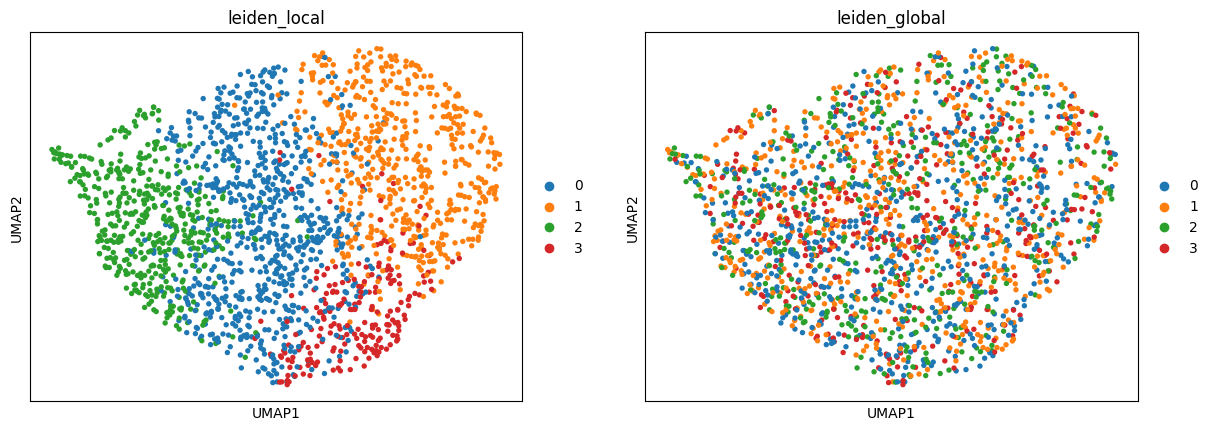

In [55]:
sc.pp.neighbors(sub_adata_ctrl)
sc.tl.umap(sub_adata_ctrl)
sc.pl.umap(sub_adata_ctrl, color = ['leiden_local', 'leiden_global'])

In [56]:
del sub_adata_ctrl.uns

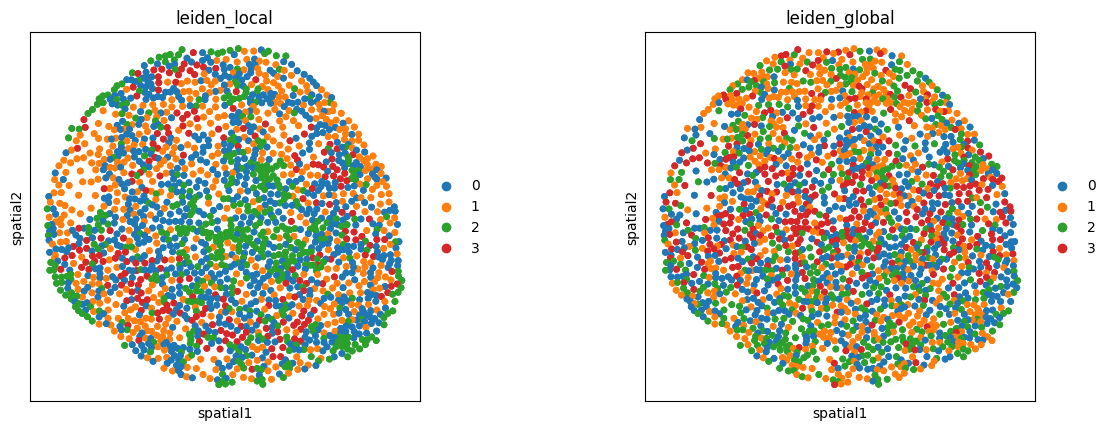

In [58]:
sq.pl.spatial_scatter(sub_adata_ctrl, 
                      color = ['leiden_local', 'leiden_global'],
                    shape = None)

In [64]:
import pandas as pd

# Contingency table of cluster overlaps
cooccurrence_matrix = pd.crosstab(sub_adata_ctrl.obs['leiden_local'], sub_adata_ctrl.obs['leiden_global'])

# Display matrix
print(cooccurrence_matrix)

leiden_global    0    1    2    3
leiden_local                     
0              233  214  180  150
1              159  157  128   92
2              131  132  109   88
3               72   66   38   35


In [75]:
import numpy as np
import pandas as pd
from itertools import combinations
from sklearn.metrics import adjusted_rand_score

def compute_cooccurrence_matrix(labels):
    """Compute a binary co-occurrence matrix for a clustering."""
    n = len(labels)
    cooccurrence = np.zeros((n, n), dtype=bool)
    for i, j in combinations(range(n), 2):  # Only upper triangle
        if labels[i] == labels[j]:
            cooccurrence[i, j] = True
            cooccurrence[j, i] = True
    return cooccurrence

# Extract cluster labels
local_labels = sub_adata_ctrl.obs['leiden_local'].values
global_labels = sub_adata_ctrl.obs['leiden_global'].values

# Compute binary co-occurrence matrices
cooccurrence_local = compute_cooccurrence_matrix(local_labels)
cooccurrence_global = compute_cooccurrence_matrix(global_labels)

# Compare agreement using Adjusted Rand Index
cooccurrence_local_flat = cooccurrence_local[np.triu_indices_from(cooccurrence_local, k=1)]
cooccurrence_global_flat = cooccurrence_global[np.triu_indices_from(cooccurrence_global, k=1)]

ari = adjusted_rand_score(cooccurrence_local_flat, cooccurrence_global_flat)
print(f"Pairwise Co-occurrence Agreement (ARI): {ari:.4f}")
jaccard = jaccard_score(cooccurrence_local_flat, cooccurrence_global_flat)
print(f"Jaccard Similarity of Pairwise Co-occurrence: {jaccard:.4f}")

Pairwise Co-occurrence Agreement (ARI): -0.0007
Jaccard Similarity of Pairwise Co-occurrence: 0.1576


In [81]:
import pandas as pd
import numpy as np

def find_overlapping_clusters(adata, threshold=20):
    """
    Identify clusters in 'leiden_local' and 'leiden_global' that share at least
    THRESHOLD% of their cells.
    
    Args:
        adata: Anndata object with 'leiden_local' and 'leiden_global' in .obs.
        threshold: Minimum percentage of shared cells to consider clusters as overlapping.
        
    Returns:
        A DataFrame showing overlapping cluster pairs and their percentage overlap.
    """
    # Crosstab to compute cell counts for cluster intersections
    contingency_table = pd.crosstab(adata.obs['leiden_local'], adata.obs['leiden_global'])
    
    # Normalize to get percentages for each row (local clusters)
    local_totals = contingency_table.sum(axis=1).values[:, np.newaxis]
    overlap_percent = (contingency_table / local_totals) * 100  # Normalize
    
    # Filter pairs exceeding the threshold
    overlapping_pairs = []
    for local_cluster in overlap_percent.index:
        for global_cluster in overlap_percent.columns:
            percent = overlap_percent.at[local_cluster, global_cluster]
            if percent >= threshold:
                overlapping_pairs.append((local_cluster, global_cluster, percent))
    
    # Convert results to a DataFrame
    overlap_df = pd.DataFrame(overlapping_pairs, columns=["leiden_local", "leiden_global", "percent_overlap"])
    return overlap_df

# Example usage
threshold = 20  # Minimum percentage threshold
overlap_df = find_overlapping_clusters(sub_adata_ctrl, threshold=threshold)

# Display results
print(f"Clusters with at least {threshold}% overlap:")
print(overlap_df)


Clusters with at least 20% overlap:
   leiden_local leiden_global  percent_overlap
0             0             0        29.987130
1             0             1        27.541828
2             0             2        23.166023
3             1             0        29.664179
4             1             1        29.291045
5             1             2        23.880597
6             2             0        28.478261
7             2             1        28.695652
8             2             2        23.695652
9             3             0        34.123223
10            3             1        31.279621


In [68]:
import plotly.graph_objects as go

# Prepare data for Sankey
local_clusters = sub_adata_ctrl.obs['leiden_local']
global_clusters = sub_adata_ctrl.obs['leiden_global']

# Assign numeric IDs to cluster names
local_ids = local_clusters.astype('category').cat.codes
global_ids = global_clusters.astype('category').cat.codes

# Count links between clusters
counts = pd.crosstab(local_ids, global_ids)

# Create source, target, and values for Sankey
sources, targets, values = [], [], []
for local, glob in zip(*counts.nonzero()):
    sources.append(local)
    targets.append(glob + len(counts))  # Offset targets
    values.append(counts.iloc[local, global])

# Sankey Diagram
fig = go.Figure(go.Sankey(
    node=dict(
        pad=15, thickness=20,
        label=list(local_clusters.astype('category').cat.categories) + 
              list(global_clusters.astype('category').cat.categories),
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values
    )
))

fig.update_layout(title_text="Cluster Overlap between leiden_local and leiden_global", font_size=10)
fig.show()

ModuleNotFoundError: No module named 'plotly'

Can we find more overlap in clusters for control vs SHH?

In [60]:
# Perform DGE analysis
sc.tl.rank_genes_groups(sub_adata_ctrl, groupby='leiden_local', method='wilcoxon', key_added = 'dge_wilcoxon_local')
sc.tl.rank_genes_groups(sub_adata_ctrl, groupby='leiden_global', method='wilcoxon', key_added = 'dge_wilcoxon_global')

### Condition: SHH

In [9]:
H_GNN = trans_in_dict_shh['None'].detach().numpy().squeeze(1)
H_T = trans_out_dict_shh['None'].detach().numpy().squeeze(1)[1:, :]
print(f'Shape of local ({H_GNN.shape}) and global embeddings ({H_T.shape}).')

Shape of local ((1779, 128)) and global embeddings ((1779, 128)).


In [10]:
from sklearn.preprocessing import StandardScaler
import umap

# 1. UMAP of embedding
scaler = StandardScaler()
H_GNN_normalized = scaler.fit_transform(H_GNN)
H_T_normalized = scaler.fit_transform(H_T)

# Apply UMAP
umap_model = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
H_GNN_umap = umap_model.fit_transform(H_GNN_normalized)
H_T_umap = umap_model.fit_transform(H_T_normalized)

In [40]:
sub_adata_shh.X

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 70527 stored elements and shape (1779, 88)>

In [32]:
# Create an AnnData object for clustering
LEIDEN_RES = 0.1

adata = AnnData(X=H_GNN_umap)

# Build a KNN graph and perform Leiden clustering
sc.pp.neighbors(adata, n_neighbors=40, use_rep='X')
sc.tl.leiden(adata, resolution=LEIDEN_RES)

sub_adata_shh.obs['leiden_local'] = np.array(adata.obs['leiden'])

adata = AnnData(X=H_T_umap)

# Build a KNN graph and perform Leiden clustering
sc.pp.neighbors(adata, n_neighbors=40, use_rep='X')
sc.tl.leiden(adata, resolution=LEIDEN_RES)

# Extract Leiden clusters
sub_adata_shh.obs['leiden_global'] = np.array(adata.obs['leiden'])
print(f"Nr. of clusters: local = {len(np.unique(sub_adata_shh.obs['leiden_local']))}, global = {len(np.unique(sub_adata_shh.obs['leiden_global']))}")

Nr. of clusters: local = 5, global = 6


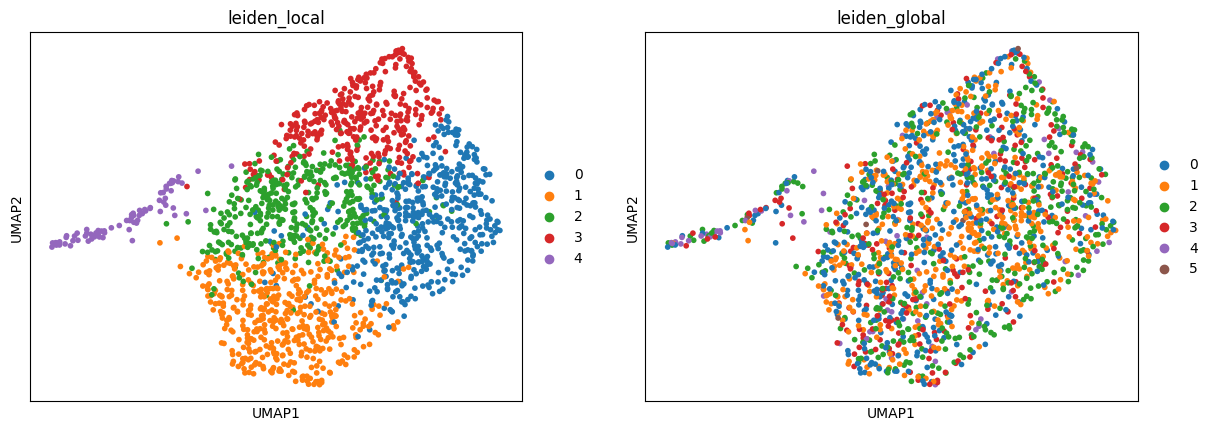

In [33]:
sc.pp.neighbors(sub_adata_shh)
sc.tl.umap(sub_adata_shh)
sc.pl.umap(sub_adata_shh, color = ['leiden_local', 'leiden_global'])

In [65]:
import pandas as pd

# Contingency table of cluster overlaps
cooccurrence_matrix = pd.crosstab(sub_adata_shh.obs['leiden_local'], sub_adata_shh.obs['leiden_global'])

# Display matrix
print(cooccurrence_matrix)

leiden_global    0    1    2   3   4  5
leiden_local                           
0              111  132  165  60  18  1
1              141  125  110  80  19  1
2              113  131   81  59  10  4
3              116   87   83  43  12  1
4               16    4   21  13  21  1


In [34]:
del sub_adata_shh.uns

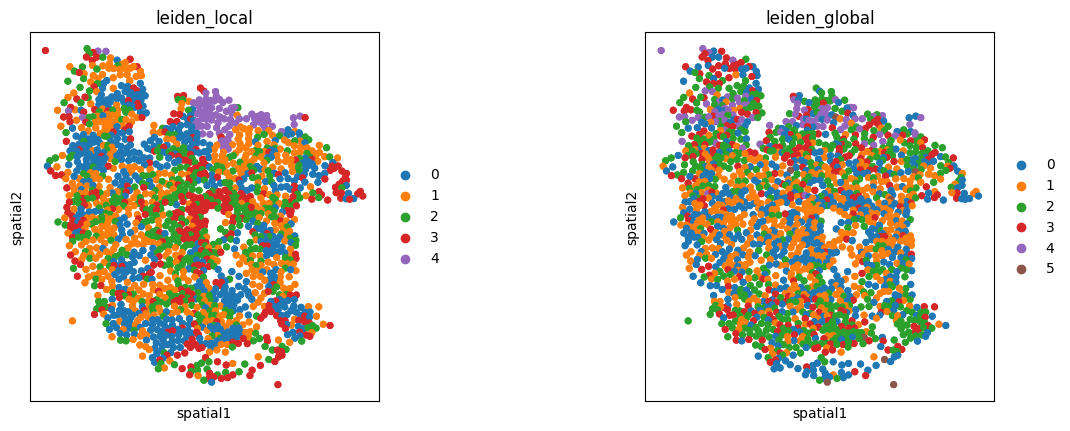

In [35]:
sq.pl.spatial_scatter(sub_adata_shh, 
                      color = ['leiden_local', 'leiden_global'],
                    shape = None)

Cell Pair Co-occurrence Agreement

Steps:
1. Generate all cell pairs (i.e., combinations of cells 
2. For each clustering (leiden_local and leiden_global), identify if two cells are in the same cluster (binary flag).
3. Compare the co-occurrence of pairs between the two clusterings.

In [74]:
import numpy as np
import pandas as pd
from itertools import combinations
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics import jaccard_score

def compute_cooccurrence_matrix(labels):
    """Compute a binary co-occurrence matrix for a clustering."""
    n = len(labels)
    cooccurrence = np.zeros((n, n), dtype=bool)
    for i, j in combinations(range(n), 2):  # Only upper triangle
        if labels[i] == labels[j]:
            cooccurrence[i, j] = True
            cooccurrence[j, i] = True
    return cooccurrence

# Extract cluster labels
local_labels = sub_adata_shh.obs['leiden_local'].values
global_labels = sub_adata_shh.obs['leiden_global'].values

# Compute binary co-occurrence matrices
cooccurrence_local = compute_cooccurrence_matrix(local_labels)
cooccurrence_global = compute_cooccurrence_matrix(global_labels)

# Compare agreement using Adjusted Rand Index
cooccurrence_local_flat = cooccurrence_local[np.triu_indices_from(cooccurrence_local, k=1)]
cooccurrence_global_flat = cooccurrence_global[np.triu_indices_from(cooccurrence_global, k=1)]

ari = adjusted_rand_score(cooccurrence_local_flat, cooccurrence_global_flat)
print(f"Pairwise Co-occurrence Agreement (ARI): {ari:.4f}")
jaccard = jaccard_score(cooccurrence_local_flat, cooccurrence_global_flat)
print(f"Jaccard Similarity of Pairwise Co-occurrence: {jaccard:.4f}")

Pairwise Co-occurrence Agreement (ARI): 0.0052
Jaccard Similarity of Pairwise Co-occurrence: 0.1404


In [82]:
import pandas as pd
import numpy as np

def find_overlapping_clusters(adata, threshold=10):
    """
    Identify clusters in 'leiden_local' and 'leiden_global' that share at least
    THRESHOLD% of their cells.
    
    Args:
        adata: Anndata object with 'leiden_local' and 'leiden_global' in .obs.
        threshold: Minimum percentage of shared cells to consider clusters as overlapping.
        
    Returns:
        A DataFrame showing overlapping cluster pairs and their percentage overlap.
    """
    # Crosstab to compute cell counts for cluster intersections
    contingency_table = pd.crosstab(adata.obs['leiden_local'], adata.obs['leiden_global'])
    
    # Normalize to get percentages for each row (local clusters)
    local_totals = contingency_table.sum(axis=1).values[:, np.newaxis]
    overlap_percent = (contingency_table / local_totals) * 100  # Normalize
    
    # Filter pairs exceeding the threshold
    overlapping_pairs = []
    for local_cluster in overlap_percent.index:
        for global_cluster in overlap_percent.columns:
            percent = overlap_percent.at[local_cluster, global_cluster]
            if percent >= threshold:
                overlapping_pairs.append((local_cluster, global_cluster, percent))
    
    # Convert results to a DataFrame
    overlap_df = pd.DataFrame(overlapping_pairs, columns=["leiden_local", "leiden_global", "percent_overlap"])
    return overlap_df

# Example usage
threshold = 20  # Minimum percentage threshold
overlap_df = find_overlapping_clusters(sub_adata_shh, threshold=threshold)

# Display results
print(f"Clusters with at least {threshold}% overlap:")
print(overlap_df)

Clusters with at least 20% overlap:
   leiden_local leiden_global  percent_overlap
0             0             0        22.792608
1             0             1        27.104723
2             0             2        33.880903
3             1             0        29.621849
4             1             1        26.260504
5             1             2        23.109244
6             2             0        28.391960
7             2             1        32.914573
8             2             2        20.351759
9             3             0        33.918129
10            3             1        25.438596
11            3             2        24.269006
12            4             0        21.052632
13            4             2        27.631579
14            4             4        27.631579


In [37]:
# Perform DGE analysis
sc.tl.rank_genes_groups(sub_adata_shh, groupby='leiden_local', method='wilcoxon', key_added = 'dge_wilcoxon_local')
sc.tl.rank_genes_groups(sub_adata_shh, groupby='leiden_global', method='wilcoxon', key_added = 'dge_wilcoxon_global')

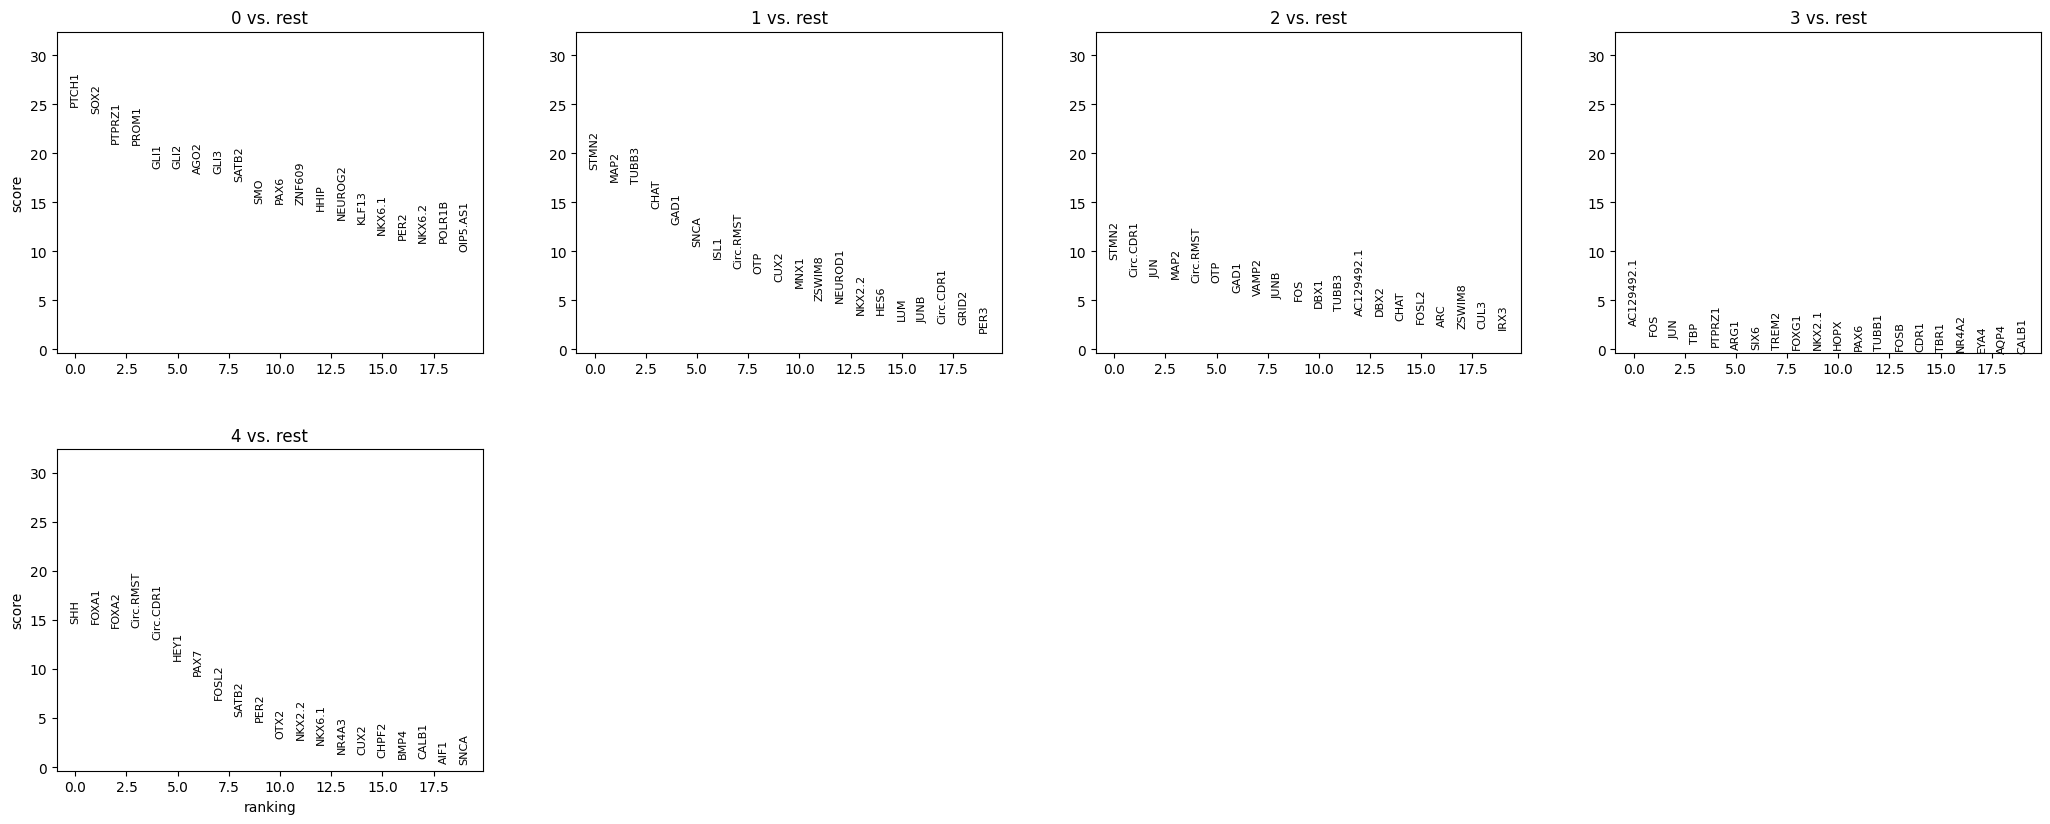

In [38]:
sc.pl.rank_genes_groups(sub_adata_shh, key = 'dge_wilcoxon_local')

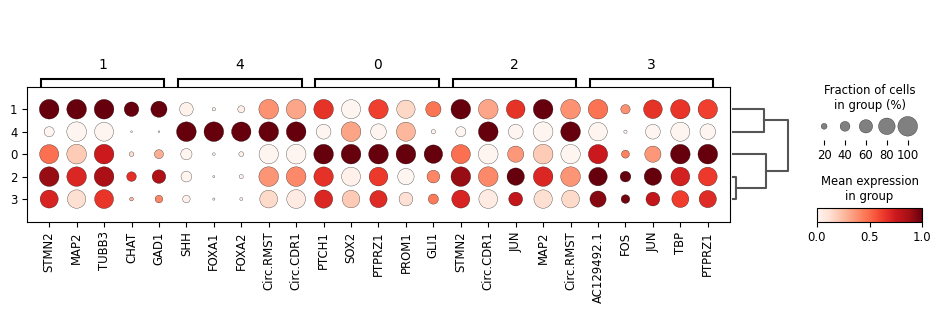

In [44]:
sc.pl.rank_genes_groups_dotplot(
    sub_adata_shh,
    groupby="leiden_local",
    standard_scale="var",
    n_genes=5,
    key="dge_wilcoxon_local",
)

In [ ]:
local_genes = {
    "1": ["PTCH1"]

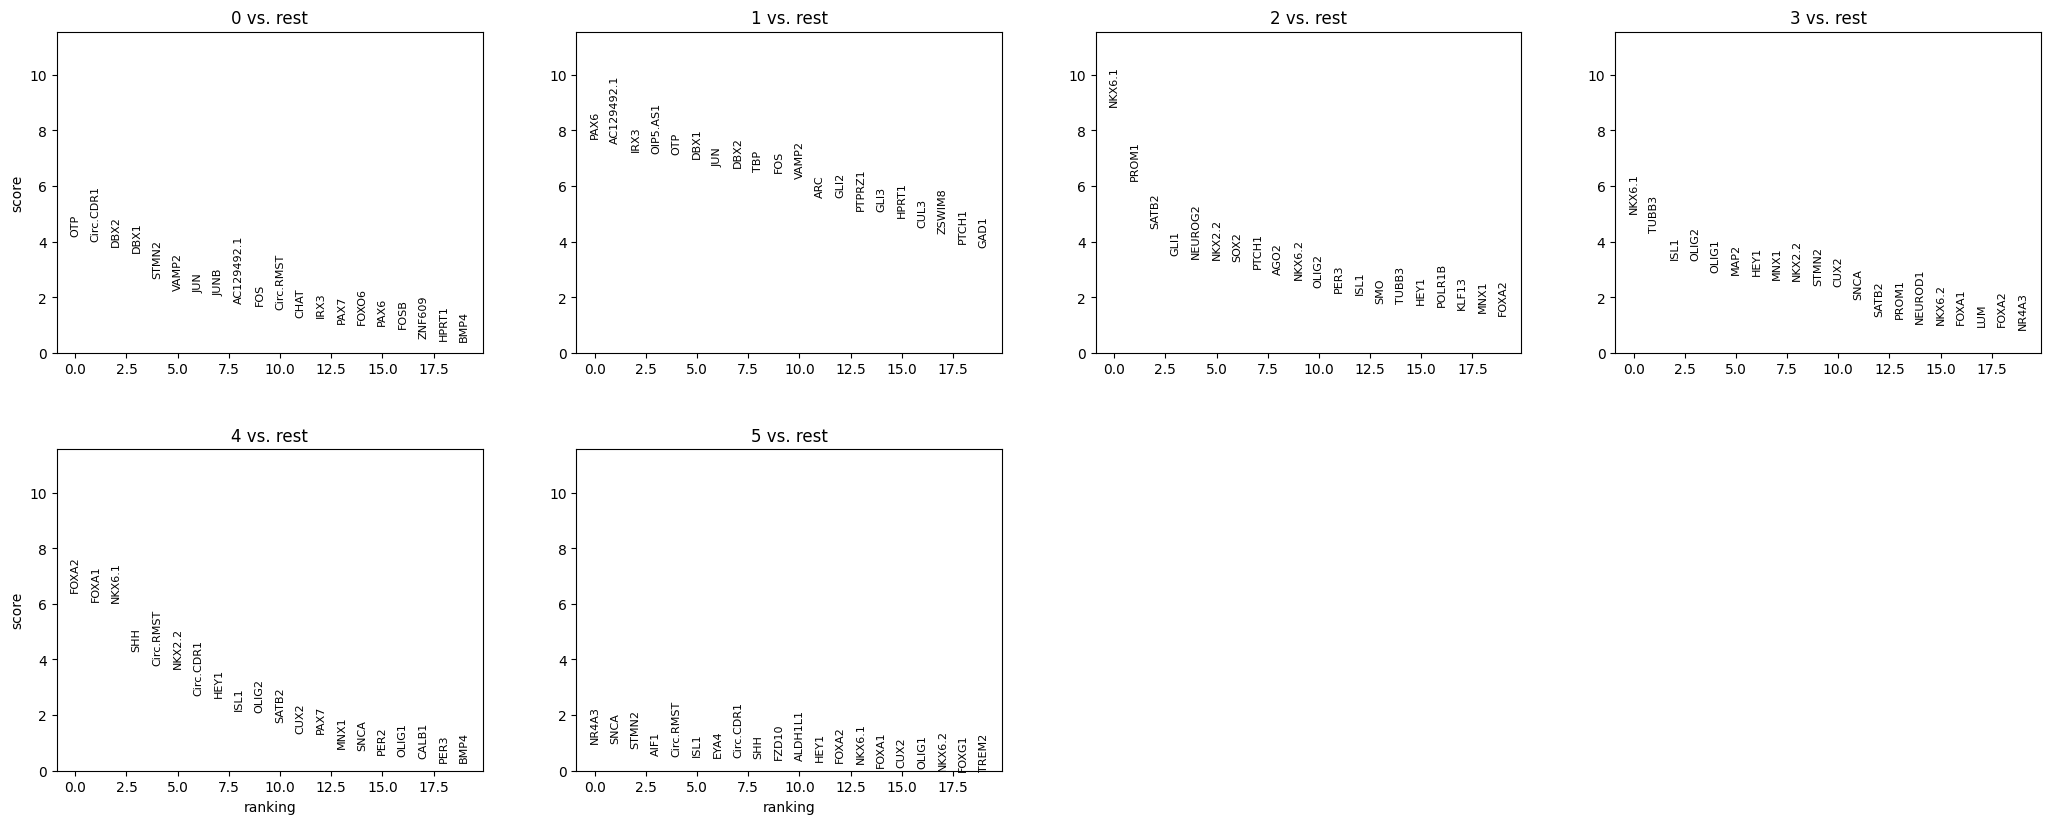

In [39]:
sc.pl.rank_genes_groups(sub_adata_shh, key = 'dge_wilcoxon_global')

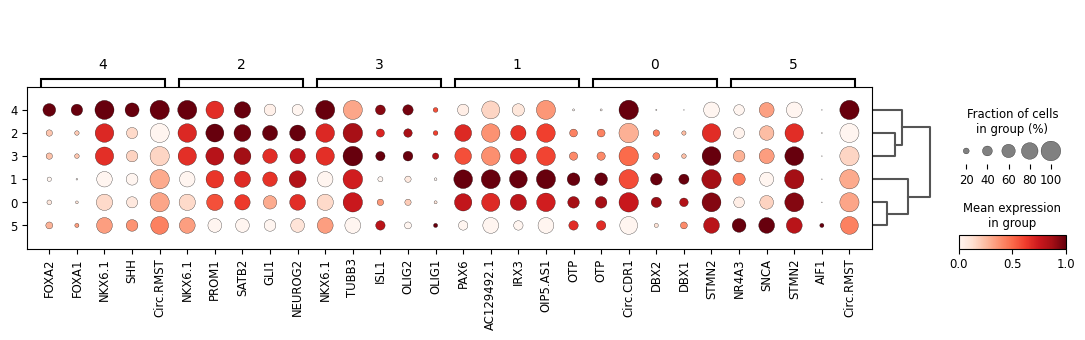

In [62]:
sc.pl.rank_genes_groups_dotplot(
    sub_adata_shh,
    groupby="leiden_global",
    standard_scale="var",
    n_genes=5,
    key="dge_wilcoxon_global",
)

   names_local  scores_local  logfoldchanges_local   pvals_local  \
83       TUBB3     -7.292929            -38.929203  3.032877e-13   
20      NKX6.1      0.600327             -6.198063  5.482882e-01   
85        MAP2     -9.356052            -20.957851  8.277187e-21   
76         SHH     -4.201439            -10.995810  2.652241e-05   
75        ISL1     -4.168283             -4.024068  3.069024e-05   
11     NEUROG2      1.915231             -0.910970  5.546303e-02   
10       SATB2      1.917421             -0.503780  5.518444e-02   

    pvals_adj_local names_global  scores_global  logfoldchanges_global  \
83     5.337863e-12        TUBB3       1.994865               9.370874   
20     8.177858e-01       NKX6.1       7.625275              19.000261   
85     2.427975e-19         MAP2       0.723459               1.681752   
76     1.111415e-04          SHH       0.253928               0.576047   
75     1.227610e-04         ISL1       1.965968               0.824081   
11     1.68

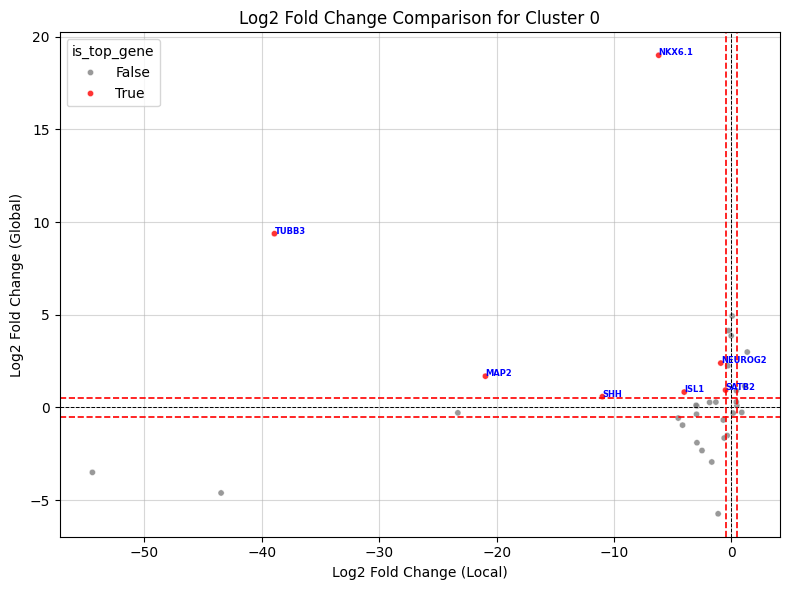

   names_local  scores_local  logfoldchanges_local    pvals_local  \
83       TUBB3    -20.633360            -73.779984   1.377404e-94   
73       STMN2    -16.050150            -67.110573   5.702683e-58   
86        MAP2    -21.582178            -36.590168  2.641277e-103   
52        GAD1     -9.521338             -6.715765   1.709635e-21   
34        DBX1     -2.689036             -4.832375   7.165878e-03   
38        ISL1     -4.189178             -4.111132   2.799663e-05   
47         OTP     -8.035430             -4.229039   9.325102e-16   

    pvals_adj_local names_global  scores_global  logfoldchanges_global  \
83     2.424232e-93        TUBB3       0.854006               7.116604   
73     3.345574e-57        STMN2       2.488218              12.538781   
86    1.162162e-101         MAP2       0.989084               3.029395   
52     4.179108e-21         GAD1       1.131145               1.200437   
34     1.167773e-02         DBX1       1.279939               1.311637   
38 

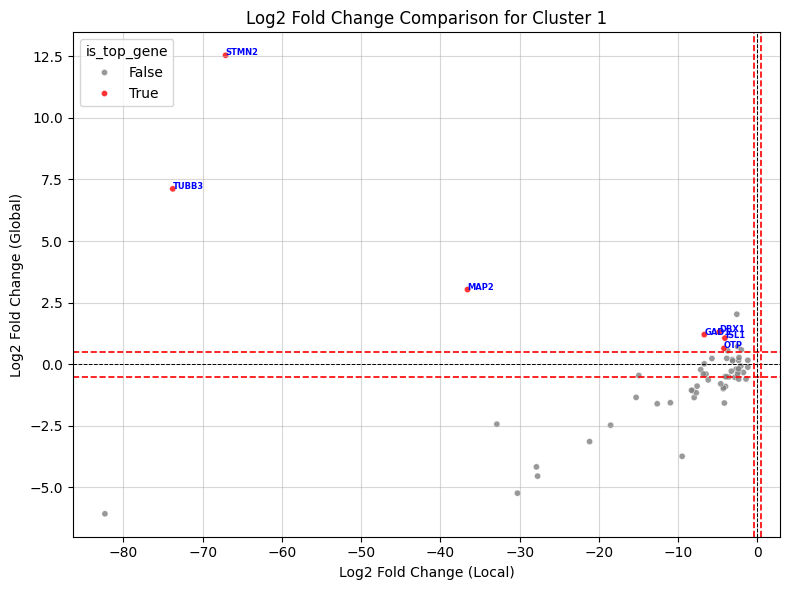

   names_local  scores_local  logfoldchanges_local    pvals_local  \
0        STMN2     24.097334            159.448715  2.665873e-128   
1        TUBB3     23.587988            143.115829  5.119470e-123   
3    Circ.CDR1     18.320635             88.012718   5.664857e-75   
2         MAP2     23.564470             67.232841  8.921770e-123   
15      NKX6.1     11.767864             40.664387   5.715344e-32   
4    Circ.RMST     18.140793             33.463833   1.518263e-73   
22       PTCH1      9.256804             16.783379   2.106438e-20   

    pvals_adj_local names_global  scores_global  logfoldchanges_global  \
0     2.345968e-126        STMN2       0.360842              -2.861741   
1     2.252567e-121        TUBB3      -2.098823             -13.117414   
3      1.246269e-73    Circ.CDR1      -0.678367              -7.776848   
2     2.617053e-121         MAP2      -2.087909              -4.329010   
15     3.143439e-31       NKX6.1      -9.063762             -24.040485   
4  

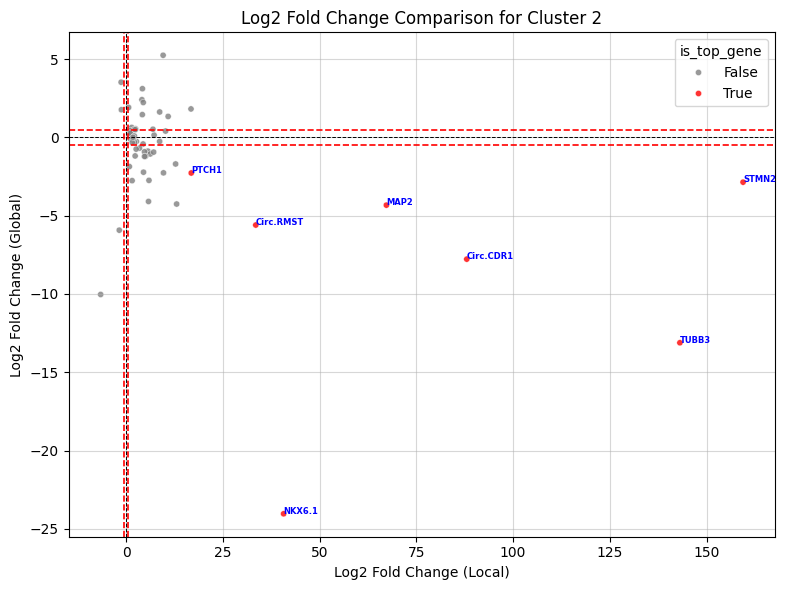

   names_local  scores_local  logfoldchanges_local   pvals_local  \
1        PTCH1     20.611822             49.639809  2.149852e-94   
0         SOX2     20.890640             48.499592  6.513930e-97   
7         PAX6     16.707762             40.436966  1.150759e-62   
2       PTPRZ1     20.281317             34.899132  1.880328e-91   
5         GLI3     18.414360             16.881218  1.007722e-75   
6       ZNF609     17.522047             16.756752  9.726141e-69   
34        DBX1      5.978757             11.351398  2.248463e-09   

    pvals_adj_local names_global  scores_global  logfoldchanges_global  \
1      9.459350e-93        PTCH1      -1.147130              -2.212674   
0      5.732258e-95         SOX2      -0.767239              -2.346878   
7      1.265834e-61         PAX6      -4.844287              -7.528138   
2      5.515629e-90       PTPRZ1      -3.025299              -5.504136   
5      1.477993e-74         GLI3      -3.527753              -2.283854   
6      1.22

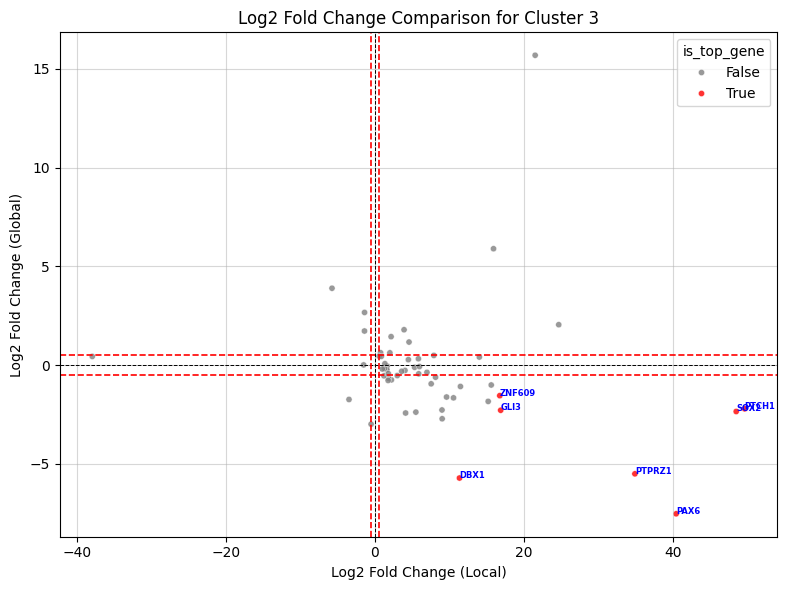

   names_local  scores_local  logfoldchanges_local   pvals_local  \
87        SOX2    -10.985765            -22.801043  4.474364e-28   
76        PAX6     -6.370736            -14.421203  1.881230e-10   
85      PTPRZ1     -8.648985            -13.986334  5.195968e-18   
7    Circ.RMST      2.912942             -6.135388  3.580409e-03   
75      ZNF609     -6.104929             -6.681272  1.028462e-09   
83        GLI3     -8.270132             -6.234293  1.338110e-16   
2         MAP2      5.671339              3.245893  1.416861e-08   

    pvals_adj_local names_global  scores_global  logfoldchanges_global  \
87     3.937440e-26         SOX2       0.616221               0.713227   
76     1.182488e-09         PAX6       1.396145               3.222932   
85     1.143113e-16       PTPRZ1       1.038886               1.296938   
7      9.266942e-03    Circ.RMST       1.914296               3.069128   
75     6.033642e-09       ZNF609       1.459879               1.316843   
83     1.96

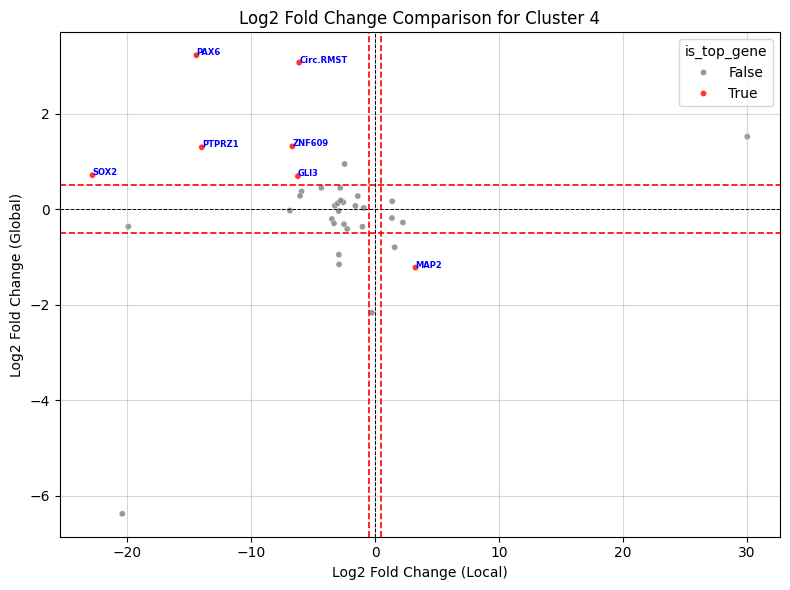

   names_local  scores_local  logfoldchanges_local   pvals_local  \
60   Circ.CDR1     -5.766244            -38.343689  8.105747e-09   
70       VAMP2     -7.308142             -8.183525  2.708618e-13   
63    OIP5.AS1     -6.245313             -6.663782  4.229524e-10   
65        CUL3     -6.883249             -4.219186  5.850265e-12   
71         TBP     -7.835340             -4.624907  4.675758e-15   
74        PER2     -8.468344             -3.485600  2.489070e-17   
49     NEUROD1     -2.961045             -2.823712  3.065977e-03   

    pvals_adj_local names_global  scores_global  logfoldchanges_global  \
60     2.547520e-08    Circ.CDR1       1.402446               5.937922   
70     1.324213e-12        VAMP2       1.884419               2.572982   
63     1.488792e-09     OIP5.AS1       1.633780               2.154182   
65     2.238362e-11         CUL3       1.077620               0.921792   
71     2.420392e-14          TBP       0.643748               0.512459   
74     1.56

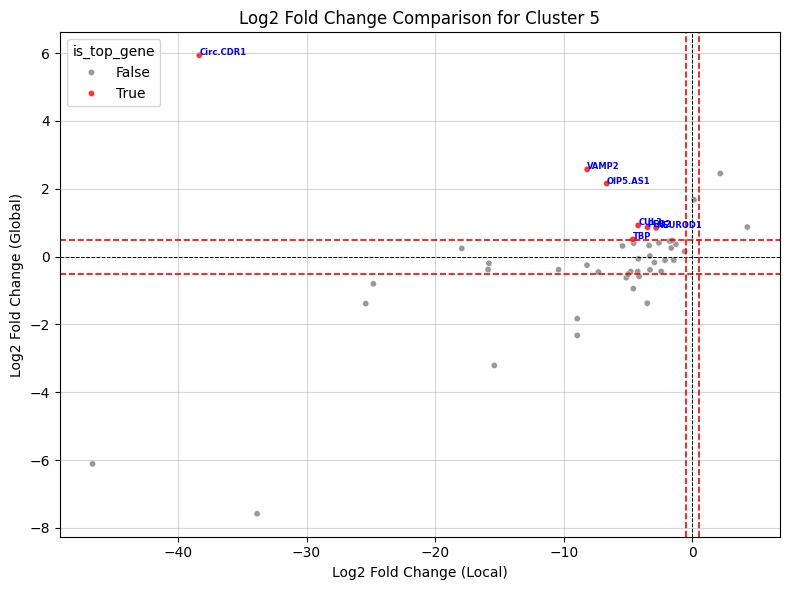

   names_local  scores_local  logfoldchanges_local   pvals_local  \
2        TUBB3      8.162822             34.199471  3.272863e-16   
3        STMN2      7.966324             36.073933  1.634639e-15   
6    Circ.CDR1      5.681229             14.820908  1.337301e-08   
4    Circ.RMST      6.250389              6.847649  4.094318e-10   
14        SNCA      4.029720              1.182726  5.584343e-05   

    pvals_adj_local names_global  scores_global  logfoldchanges_global  \
2      9.600398e-15        TUBB3      -0.492469              -6.030195   
3      3.596206e-14        STMN2       0.050436              -3.127159   
6      1.681179e-07    Circ.CDR1       0.810689              -5.026483   
4      7.206000e-09    Circ.RMST      -0.404164              -5.741979   
14     3.276148e-04         SNCA      -1.675441              -0.643841   

    pvals_global  pvals_adj_global  log2FC_local_global  
2       0.622388          0.995820            40.229664  
3       0.959775          1.00

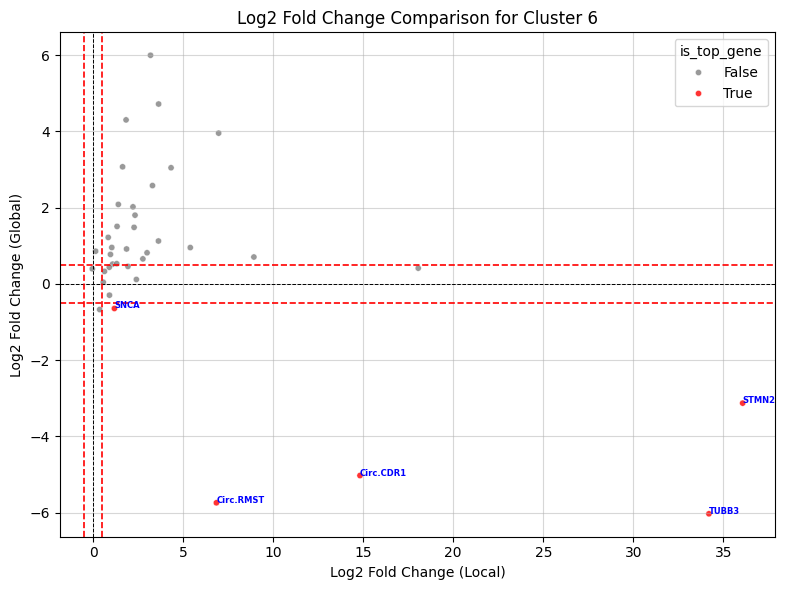

   names_local  scores_local  logfoldchanges_local   pvals_local  \
0        STMN2     10.757398             81.282990  5.469275e-27   
2    Circ.CDR1      7.084774             32.362614  1.392709e-12   
87        SOX2     -6.615084            -21.088627  3.713422e-11   
71        PAX6     -2.099939            -10.869570  3.573424e-02   
85       PTCH1     -4.660934            -17.207460  3.147778e-06   
5        TUBB3      5.787064             21.313911  7.162756e-09   
82      PTPRZ1     -3.562700            -10.080220  3.670596e-04   

    pvals_adj_local names_global  scores_global  logfoldchanges_global  \
0      4.812962e-25        STMN2      -0.544220             -11.732486   
2      4.085279e-11    Circ.CDR1      -0.652278              -8.593316   
87     6.535622e-10         SOX2       3.103769               9.092799   
71     1.014391e-01         PAX6       6.370072              14.540917   
85     2.518222e-05        PTCH1       3.113414               7.587891   
5      9.00

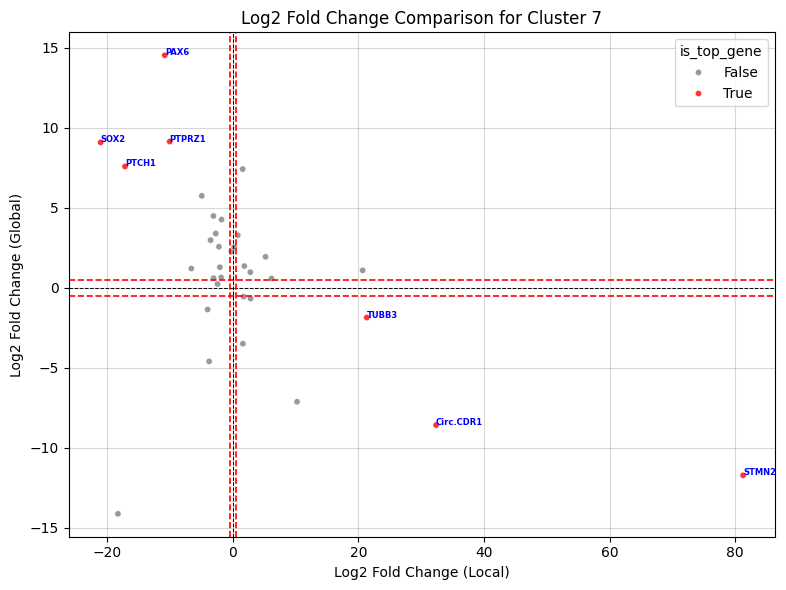

   names_local  scores_local  logfoldchanges_local   pvals_local  \
13      NKX2.2      2.516098             -0.758465  1.186621e-02   
58       OLIG2     -3.100623             -4.999476  1.931140e-03   
75      NKX6.2     -6.454234             -4.402121  1.087677e-10   

    pvals_adj_local names_global  scores_global  logfoldchanges_global  \
13     2.373243e-02       NKX2.2       3.869579               5.412226   
58     4.046198e-03        OLIG2       2.231884               1.017730   
75     4.557886e-10       NKX6.2      -0.017483               0.952742   

    pvals_global  pvals_adj_global  log2FC_local_global  
13      0.000109          0.000564             6.170691  
58      0.025623          0.072367             6.017207  
75      0.986052          1.000000             5.354863  


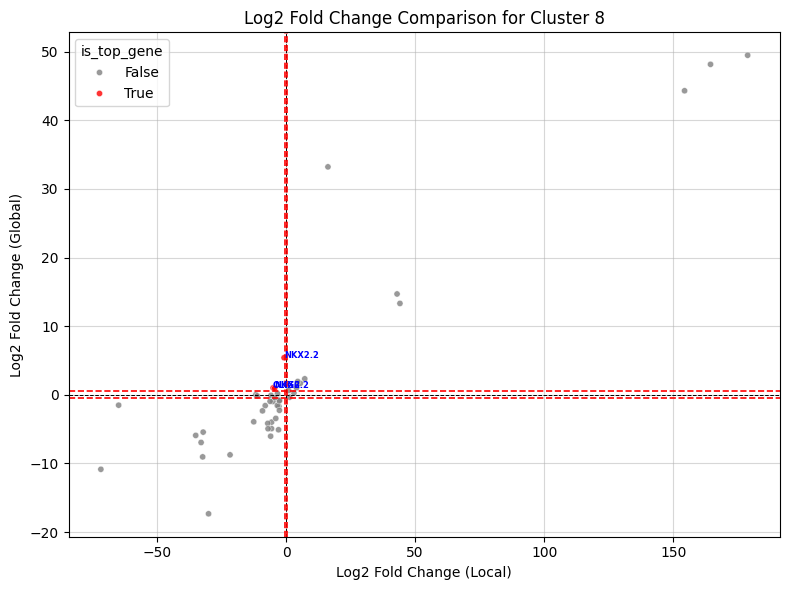

   names_local  scores_local  logfoldchanges_local   pvals_local  \
0       NKX6.1     10.628220             53.208107  2.202770e-26   
86       STMN2     -7.171062            -56.964146  7.441844e-13   
1        PTCH1     10.065289             34.555801  7.865629e-24   
3         SOX2      8.921743             26.816406  4.590032e-19   
5       PTPRZ1      8.473633             18.709230  2.378572e-17   
14        PAX6      5.688059             10.176782  1.284910e-08   
10      ZNF609      6.586493              7.424317  4.503381e-11   

    pvals_adj_local names_global  scores_global  logfoldchanges_global  \
0      1.938437e-24       NKX6.1      -0.140720              -6.569313   
86     5.457352e-12        STMN2       0.110024               2.343158   
1      3.460877e-22        PTCH1      -2.484678             -21.355824   
3      1.009807e-17         SOX2      -1.910415             -18.899845   
5      2.990205e-16       PTPRZ1      -2.619190             -16.675104   
14     6.28

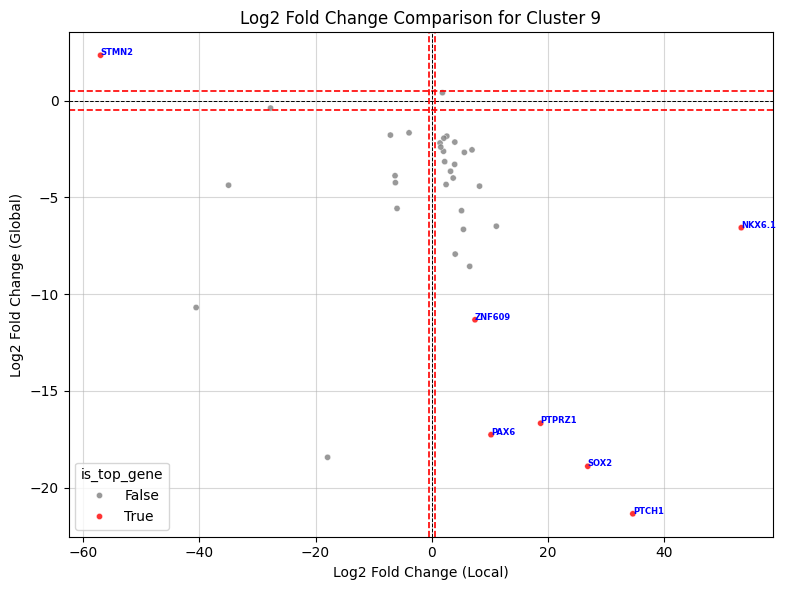

In [27]:
merged_cluster_df = {}
cluster_sig_gene_names = {}

LOGFC_THRESHOLD = 0.5
NR_TOP_GENES = 7

for cluster in np.unique(sub_adata_shh.obs['leiden_local']):  
    cluster_str = str(cluster)
    
    df_local = sc.get.rank_genes_groups_df(sub_adata_shh, cluster_str, key="dge_wilcoxon_local")
    df_global = sc.get.rank_genes_groups_df(sub_adata_shh, cluster_str, key="dge_wilcoxon_global")

    df_local = df_local.rename(columns=lambda x: f"{x}_local")
    df_global = df_global.rename(columns=lambda x: f"{x}_global")
    merged_df = pd.merge(df_local, df_global, left_on="names_local", right_on="names_global")

    merged_df = merged_df[
        (merged_df["pvals_adj_local"] <= 0.05) | (merged_df["pvals_adj_global"] <= 0.05)
    ]
    
    merged_cluster_df[cluster_str] = merged_df
    

    filtered_genes = merged_df[
        ((merged_df['logfoldchanges_local'] > LOGFC_THRESHOLD) & (merged_df['logfoldchanges_global'] < -LOGFC_THRESHOLD)) |
        ((merged_df['logfoldchanges_local'] < -LOGFC_THRESHOLD) & (merged_df['logfoldchanges_global'] > LOGFC_THRESHOLD))
    ]
    
    filtered_genes["log2FC_local_global"] = (
        filtered_genes['logfoldchanges_global'].abs() + filtered_genes['logfoldchanges_local'].abs()
    )

    top_genes = filtered_genes.sort_values(by="log2FC_local_global", ascending=False).head(NR_TOP_GENES)

    print(top_genes)
    cluster_sig_gene_names[cluster_str] = list(top_genes["names_local"])
    
    # Highlight the top genes in the scatter plot
    plt.figure(figsize=(8, 6))
    
    # Add a new column to `merged_df` indicating if a gene is among the top genes
    merged_df['is_top_gene'] = merged_df['names_local'].isin(top_genes['names_local'])
    
    # Scatter plot for all genes
    sns.scatterplot(
        x="logfoldchanges_local",
        y="logfoldchanges_global",
        data=merged_df,
        hue="is_top_gene",  # Color by whether the gene is a top gene
        palette={True: "red", False: "gray"},  # Red for top genes, gray for others
        alpha=0.8,
        s=20  # Adjust marker size
    )
    
    # Annotate top genes on the scatter plot
    for _, row in top_genes.iterrows():
        plt.text(
            row["logfoldchanges_local"],
            row["logfoldchanges_global"],
            row["names_local"],  # Gene name
            fontsize=6,
            color="blue",
            weight="bold"
    )
    
    # Add title and axis labels
    plt.title(f"Log2 Fold Change Comparison for Cluster {cluster_str}")
    plt.xlabel("Log2 Fold Change (Local)")
    plt.ylabel("Log2 Fold Change (Global)")
    
    # Add reference lines
    plt.axhline(0, color="black", linestyle="--", linewidth=0.7)
    plt.axhline(-0.5, color="red", linestyle="--", linewidth=1.2)
    plt.axhline(0.5, color="red", linestyle="--", linewidth=1.2)
    plt.axvline(0, color="black", linestyle="--", linewidth=0.7)
    plt.axvline(-0.5, color="red", linestyle="--", linewidth=1.2)
    plt.axvline(0.5, color="red", linestyle="--", linewidth=1.2)
    
    # Adjust layout and grid
    plt.grid(True, alpha=0.5)
    plt.tight_layout()
    plt.show()


In [29]:
# Combine DGE results across all clusters for local and global conditions
all_local_dge = []
all_global_dge = []

for cluster in np.unique(sub_adata_shh.obs['leiden_local']):  
    cluster_str = str(cluster)
    df_local = sc.get.rank_genes_groups_df(sub_adata_shh, cluster_str, key="dge_wilcoxon_local")
    df_global = sc.get.rank_genes_groups_df(sub_adata_shh, cluster_str, key="dge_wilcoxon_global")
    
    all_local_dge.append(df_local)
    all_global_dge.append(df_global)

# Concatenate DataFrames
local_dge = pd.concat(all_local_dge)
global_dge = pd.concat(all_global_dge)

# Merge local and global DGE by gene names
merged_dge = pd.merge(
    local_dge.rename(columns=lambda x: f"{x}_local"),
    global_dge.rename(columns=lambda x: f"{x}_global"),
    left_on="names_local",
    right_on="names_global"
)

# Filter significant genes
merged_dge = merged_dge[
    (merged_dge["pvals_adj_local"] <= 0.05) | (merged_dge["pvals_adj_global"] <= 0.05)
]

# Add a column for absolute log2 fold-change difference
merged_dge["log2FC_diff"] = (merged_dge["logfoldchanges_local"] - merged_dge["logfoldchanges_global"]).abs()

# Rank by log2 fold-change difference
top_genes = merged_dge.sort_values("log2FC_diff", ascending=False).head(20)

print(top_genes)


     names_local  scores_local  logfoldchanges_local    pvals_local  \
7089   Circ.CDR1     10.555669            178.725830   4.782204e-26   
7087   Circ.CDR1     10.555669            178.725830   4.782204e-26   
7082   Circ.CDR1     10.555669            178.725830   4.782204e-26   
7081   Circ.CDR1     10.555669            178.725830   4.782204e-26   
7086   Circ.CDR1     10.555669            178.725830   4.782204e-26   
7080   Circ.CDR1     10.555669            178.725830   4.782204e-26   
7083   Circ.CDR1     10.555669            178.725830   4.782204e-26   
7042         SHH     14.597504            164.343704   2.913197e-48   
7084   Circ.CDR1     10.555669            178.725830   4.782204e-26   
7085   Circ.CDR1     10.555669            178.725830   4.782204e-26   
7047         SHH     14.597504            164.343704   2.913197e-48   
1767       STMN2     24.097334            159.448715  2.665873e-128   
7046         SHH     14.597504            164.343704   2.913197e-48   
1768  

In [43]:
from scipy.stats import spearmanr
# Calculate variance for each gene across clusters
local_variance = sub_adata_shh[:, sub_adata_shh.var_names].to_df().groupby(sub_adata_shh.obs['leiden_local']).var().mean()
global_variance = sub_adata_shh[:, sub_adata_shh.var_names].to_df().groupby(sub_adata_shh.obs['leiden_global']).var().mean()

# Merge variances
variance_df = pd.DataFrame({
    "local_variance": local_variance,
    "global_variance": global_variance
})

# Identify top variance-driving genes
variance_df["variance_diff"] = (variance_df["local_variance"] - variance_df["global_variance"]).abs()
top_genes_by_variance = variance_df.sort_values("variance_diff", ascending=False).head(20)

print(top_genes_by_variance)


           local_variance  global_variance  variance_diff
STMN2            0.615154         1.690129       1.074976
SHH              0.337357         0.986240       0.648883
TUBB3            0.357377         0.857548       0.500171
PTCH1            0.335716         0.747152       0.411436
Circ.RMST        0.328742         0.695653       0.366911
PAX6             0.738857         1.086802       0.347944
FOXA1            0.102048         0.409425       0.307377
NKX6.1           1.198808         1.499850       0.301042
PTPRZ1           0.416216         0.716146       0.299929
SOX2             0.414250         0.711403       0.297153
Circ.CDR1        0.277400         0.564368       0.286968
FOXA2            0.154303         0.428870       0.274567
MAP2             0.282998         0.527846       0.244848
PROM1            0.387498         0.584023       0.196525
NKX2.2           0.577080         0.754598       0.177518
GLI2             0.290845         0.450555       0.159710
GLI3          

#### Visualize Gene Overlap

Use Venn diagrams or upset plots to show the overlap and unique genes visually.

For more complex overlaps (e.g., multiple clusters), consider upset plots using the upsetplot library.

In [28]:
from matplotlib_venn import venn2
venn2([gnn_genes, transformer_genes], ('GNN', 'Transformer'))
plt.title('Gene Overlap between GNN and Transformer Embeddings')
plt.show()

ModuleNotFoundError: No module named 'matplotlib_venn'

In [30]:
sub_adata_shh.obs['leiden_local'] = sub_adata_shh.obs['leiden_local'].astype(str)
sub_adata_shh.obs['leiden_local']

40340    4
40341    8
40342    7
40343    3
40344    8
        ..
42114    3
42115    3
42116    4
42117    2
42118    7
Name: leiden_local, Length: 1779, dtype: object

TypeError: can only concatenate str (not "float") to str

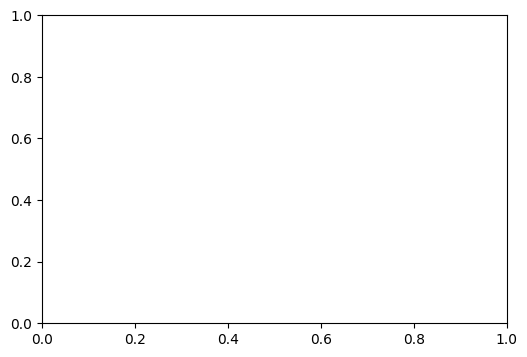

In [31]:
sub_adata_shh.X = sub_adata_shh.layers['log1p_norm']

sq.tl.var_by_distance(
    adata=sub_adata_shh,
    groups="1",
    cluster_key="shh_cluster",
    library_key="sample",
    covariates=["leiden_local"],
)
sq.pl.var_by_distance(
    adata=sub_adata_shh,
    design_matrix_key="design_matrix",
    stack_vars = True,
    var=["leiden_local"],
    anchor_key="1",
    show_scatter=False,
    figsize=(6, 4),
)

### GEX in relation with distance to SHH cluster

In [21]:
# Identify SHH center
shh_threshold = 3.7

shh_values = sub_adata_shh[:, 'SHH'].X
# If sparse, convert to dense
if issparse(shh_values):
    shh_values = shh_values.toarray()
# Ensure it's a 1D array
shh_values = shh_values.flatten()

sub_adata_shh.obs['shh_cluster'] = np.where(shh_values < shh_threshold, str(0), str(1))
#obs_gex['shh_cluster'] = np.where(shh_values < shh_threshold, str(0), str(1))

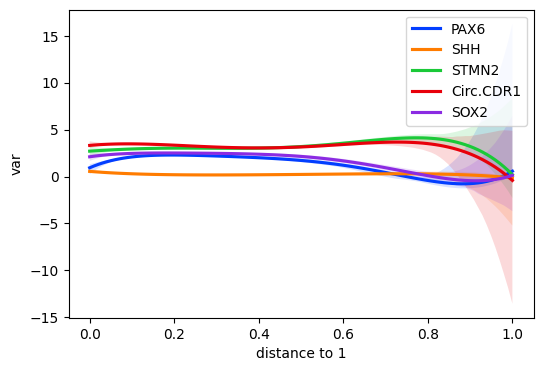

In [48]:
sub_adata_shh.X = sub_adata_shh.layers['log1p_norm']

sq.tl.var_by_distance(
    adata=sub_adata_shh,
    groups="1",
    cluster_key="shh_cluster",
    library_key="sample",
    covariates=["condition"],
)
sq.pl.var_by_distance(
    adata=sub_adata_shh,
    design_matrix_key="design_matrix",
    stack_vars = True,
    var=['PAX6', 'SHH', 'STMN2', 'Circ.CDR1', 'SOX2'],
    anchor_key="1",
    show_scatter=False,
    figsize=(6, 4),
)

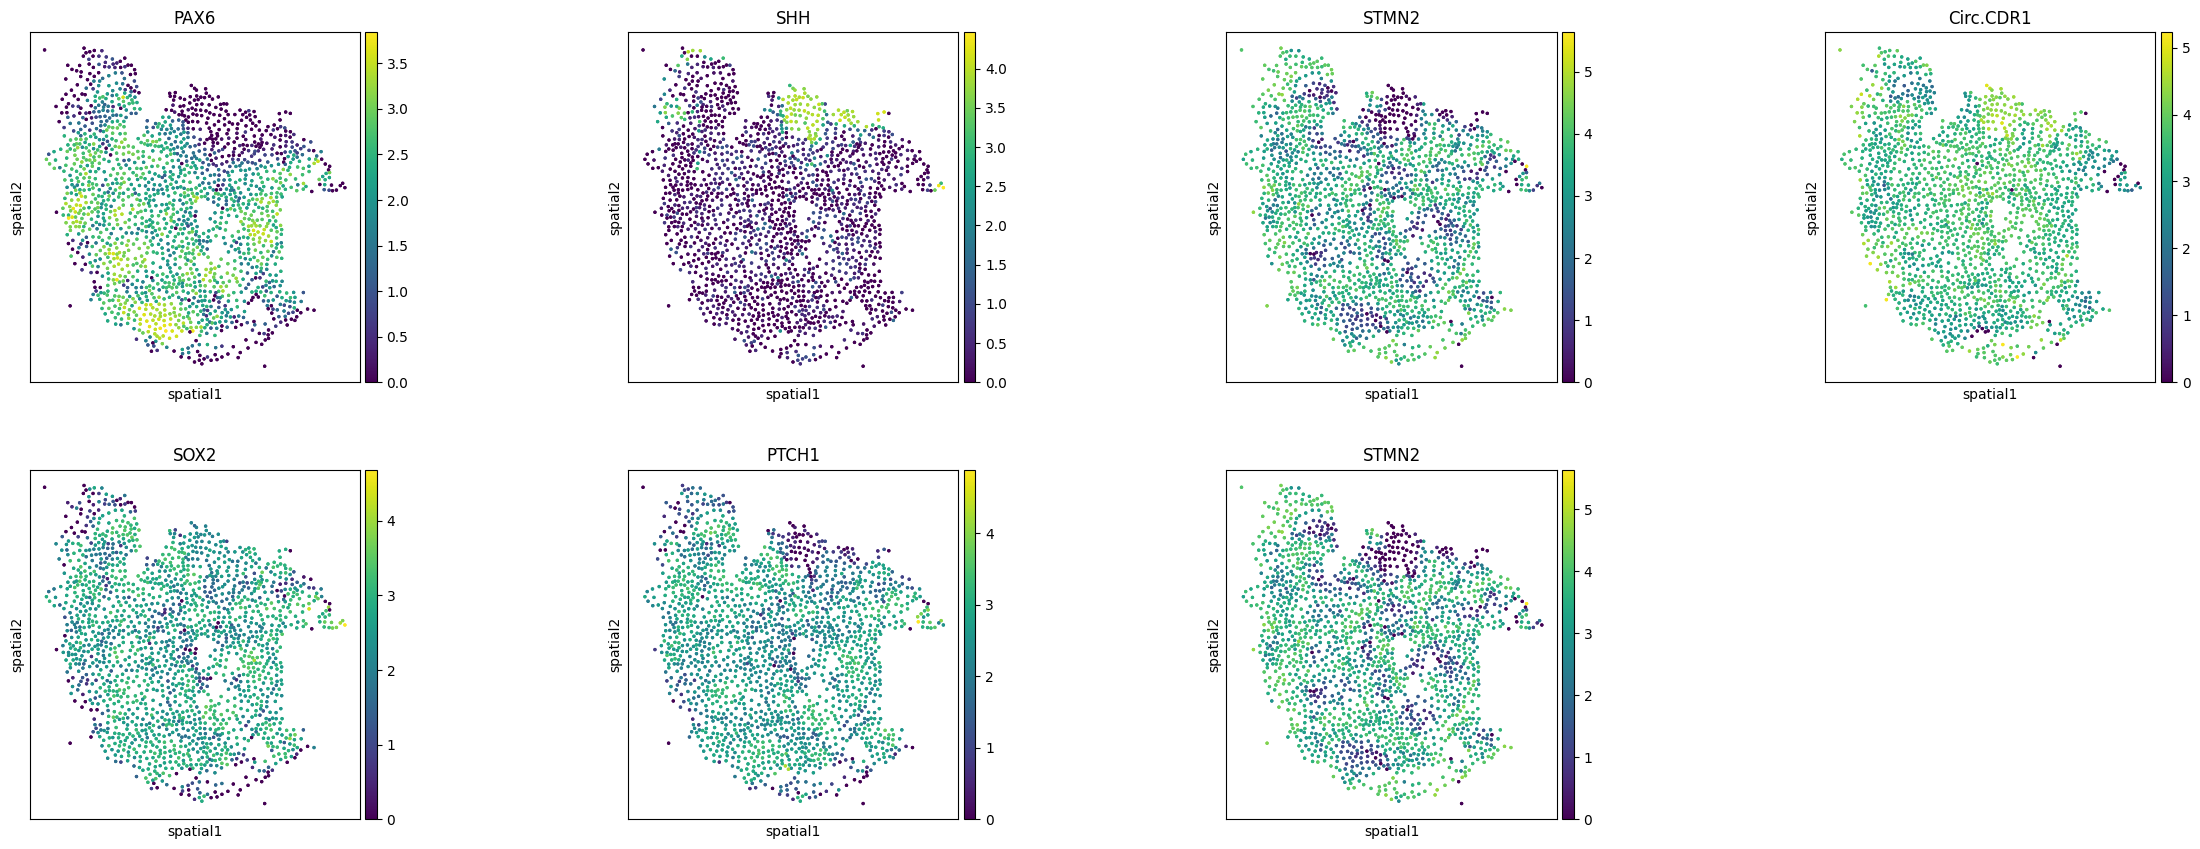

In [42]:
sq.pl.spatial_scatter(
    sub_adata_shh,
    #library_id = ['slide1_A2-1', 'slide4_B2-2'],
    color =  ['PAX6', 'SHH', 'STMN2', 'Circ.CDR1', 'SOX2', 'PTCH1', 'STMN2'],
    shape= None,
    size = 8, 
)

### Decoder based local vs global gene

In [75]:
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
from sklearn.model_selection import KFold

def compute_r2_per_gene(X_train, y_train, X_test, y_test, alpha=1.0):
    """
    Compute R^2 for each gene using Ridge regression.
    
    Parameters:
    - X_train, X_test: Embeddings (n_samples x n_features)
    - y_train, y_test: Gene expression (n_samples x n_genes)
    - alpha: Regularization strength for Ridge regression

    Returns:
    - r2_per_gene: Array of R^2 scores for each gene
    """
    n_genes = y_train.shape[1]
    r2_per_gene = []
    
    for gene_idx in range(n_genes):
        # Select the gene to predict
        y_train_gene = y_train[:, gene_idx]
        y_test_gene = y_test[:, gene_idx]
        
        # Train Ridge regression model
        model = Ridge(alpha=alpha)
        model.fit(X_train, y_train_gene)
        y_pred_gene = model.predict(X_test)
        
        # Compute R^2 for the gene
        r2_gene = r2_score(y_test_gene, y_pred_gene)
        r2_per_gene.append(r2_gene)
    
    return np.array(r2_per_gene)

def analyze_per_gene_variance(Z_GNN, Z_Transformer, Y, alpha=1.0, cv_splits=5, top_genes:int = 5):
    """
    Analyze variance explained per gene and find top genes.
    
    Parameters:
    - Z_GNN: Embeddings from GNN (n_samples x n_features)
    - Z_Transformer: Embeddings from Transformer (n_samples x n_features)
    - Y: Target gene expressions (n_samples x n_genes)
    - alpha: Regularization strength for Ridge regression
    - cv_splits: Number of cross-validation splits

    Returns:
    - top_genes_gnn: Top genes based on R^2 for Z_GNN
    - top_genes_transformer: Top genes based on R^2 for Z_Transformer
    - r2_gnn_mean: Mean R^2 scores for Z_GNN per gene
    - r2_transformer_mean: Mean R^2 scores for Z_Transformer per gene
    """
    n_genes = Y.shape[1]
    r2_gnn_all = np.zeros((cv_splits, n_genes))
    r2_transformer_all = np.zeros((cv_splits, n_genes))
    
    kf = KFold(n_splits=cv_splits, shuffle=True, random_state=42)
    for fold_idx, (train_idx, test_idx) in enumerate(kf.split(Y)):
        # Split data
        Z_GNN_train, Z_GNN_test = Z_GNN[train_idx], Z_GNN[test_idx]
        Z_Transformer_train, Z_Transformer_test = Z_Transformer[train_idx], Z_Transformer[test_idx]
        Y_train, Y_test = Y[train_idx], Y[test_idx]
        
        # Compute R^2 per gene for GNN
        r2_gnn_all[fold_idx, :] = compute_r2_per_gene(Z_GNN_train, Y_train, Z_GNN_test, Y_test, alpha)
        
        # Compute R^2 per gene for Transformer
        r2_transformer_all[fold_idx, :] = compute_r2_per_gene(Z_Transformer_train, Y_train, Z_Transformer_test, Y_test, alpha)
    
    # Mean R^2 across folds
    r2_gnn_mean = r2_gnn_all.mean(axis=0)
    r2_transformer_mean = r2_transformer_all.mean(axis=0)
    
    # Identify top genes
    top_genes_gnn = np.argsort(-r2_gnn_mean)[:top_genes]  # Top 5 genes for GNN
    top_genes_transformer = np.argsort(-r2_transformer_mean)[:top_genes]  # Top 5 genes for Transformer
    
    return top_genes_gnn, top_genes_transformer, r2_gnn_mean, r2_transformer_mean

In [80]:
Z_local_ctrl = trans_in_dict_ctrl[None].detach().numpy().squeeze(1)
Z_local_shh = trans_in_dict_shh[None].detach().numpy().squeeze(1)
Z_local.shape

(1984, 128)

In [81]:
Z_global_ctrl = trans_out_dict_ctrl[None].detach().numpy().squeeze(1)
Z_global_shh = trans_out_dict_shh[None].detach().numpy().squeeze(1)
Z_global.shape

(1984, 128)

In [84]:
# Compute per-gene R^2 and find top-performing genes
top_genes_gnn, top_genes_transformer, r2_gnn_mean, r2_transformer_mean = analyze_per_gene_variance(
    Z_local_ctrl, Z_global_ctrl, sub_adata_ctrl.X.toarray(), alpha=1.0, cv_splits=5, top_genes = 10
)

# Print results
print("Top genes for GNN (indices):", sub_adata_ctrl.var_names[top_genes_gnn])
print("Top genes for Transformer (indices):", sub_adata_ctrl.var_names[top_genes_transformer])
print("R^2 mean for GNN:", r2_gnn_mean)
print("R^2 mean for Transformer:", r2_transformer_mean)

Top genes for GNN (indices): Index(['TREM2', 'OLIG1', 'NKX2.1', 'ARG1', 'Circ.CDR1', 'Circ.RMST', 'TUBB3',
       'PAX6', 'STMN2', 'PTPRZ1'],
      dtype='object')
Top genes for Transformer (indices): Index(['TREM2', 'OLIG1', 'NKX2.1', 'ARG1', 'STMN2', 'JUN', 'TUBB3', 'MAP2',
       'PAX6', 'PROM1'],
      dtype='object')
R^2 mean for GNN: [ 0.70761254  0.81237121  0.00325397 -0.14129858 -0.10128174  0.32659594
  1.         -0.14228575 -0.27907915  0.11512198 -0.1067543  -0.28601911
  0.04751796  0.98537321  0.97846249  0.7467706   0.61926765  0.40479598
  0.53666446 -0.01605462 -0.2119559  -0.1981539   0.57134321  0.14853116
 -0.10362571  0.47658763  0.59768558  0.00536656  0.04738876  0.33579686
  0.53594     0.89027405  0.92411604  0.37651255  0.15456493  0.02762663
  0.61604801 -0.09531031  0.21482209  0.91741506 -0.16803505  0.85551598
  0.40009953  0.76991339  0.0850382  -0.22484081  0.94746277 -0.17428632
 -0.08282051  0.56625459  0.02922508  0.04362615  0.24969243  1.
 -0.09332

In [83]:
# Compute per-gene R^2 and find top-performing genes
top_genes_gnn, top_genes_transformer, r2_gnn_mean, r2_transformer_mean = analyze_per_gene_variance(
    Z_local_shh, Z_global_shh, sub_adata_shh.X.toarray(), alpha=1.0, cv_splits=5, top_genes = 10
)

# Print results
print("Top genes for GNN (indices):", sub_adata_shh.var_names[top_genes_gnn])
print("Top genes for Transformer (indices):", sub_adata_shh.var_names[top_genes_transformer])
print("R^2 mean for GNN:", r2_gnn_mean)
print("R^2 mean for Transformer:", r2_transformer_mean)

Top genes for GNN (indices): Index(['TREM2', 'FOXG1', 'NKX2.1', 'SIX6', 'Circ.CDR1', 'STMN2', 'TUBB3',
       'SHH', 'NKX6.1', 'Circ.RMST'],
      dtype='object')
Top genes for Transformer (indices): Index(['SIX6', 'TREM2', 'FOXG1', 'NKX2.1', 'STMN2', 'PAX6', 'SHH', 'NKX6.1',
       'FOXA1', 'GLI3'],
      dtype='object')
R^2 mean for GNN: [ 0.75625817  0.80025476 -0.12742233 -0.13785198 -0.16974993  0.28156282
 -0.22768347 -0.19187312 -0.07647877 -0.23390393 -0.07953691  0.40063547
  0.07452402  0.97863708  0.95358244  0.70878162  0.35275592  0.73066338
  0.66116714 -0.0986573  -0.23139522 -0.16723413  0.54276012  0.21320912
  0.29930997  0.89026849  0.86276352  0.0491073  -0.06583241  0.55975213
  0.55133294  0.76369359  0.81617991  0.10291121  0.21009226  0.33407788
  0.39425452 -0.18222106  0.50682622  0.75118876  0.63435975  0.72853041
  0.25796959  0.65013723 -0.04386036 -0.10197871  0.9364557   0.55848473
 -0.14924233 -0.00368413 -0.10488094  0.46861533  0.63291253  1.
  0.74805

In [87]:
def local_global_variance_composition(r2_gnn_mean, r2_transformer_mean, var_names, n_genes=10):
    """
    Plot normalized variance composition for the top `n_genes` genes with the highest variance explained.
    
    Parameters:
    - r2_gnn_mean: Array of variance explained by the GNN.
    - r2_transformer_mean: Array of variance explained by the Transformer.
    - var_names: List of gene names corresponding to the variance arrays.
    - n_genes: Number of top genes to plot based on total explained variance.
    """
    # Compute unexplained variance (1 - max variance explained by GNN or Transformer)
    unexplained_variance = 1 - np.maximum(r2_gnn_mean, r2_transformer_mean)
    
    # Total variance normalization (Local + Global + Noise)
    total_variance = r2_gnn_mean + r2_transformer_mean + unexplained_variance
    
    # Normalize variances
    normalized_local = r2_gnn_mean / total_variance
    normalized_global = r2_transformer_mean / total_variance
    normalized_noise = unexplained_variance / total_variance
    
    # Rank genes by total explained variance (GNN + Transformer)
    explained_variance = r2_gnn_mean + r2_transformer_mean
    top_indices = np.argsort(-explained_variance)[:n_genes]  # Get indices of top genes
    
    # Select top genes and their corresponding variances
    top_local = normalized_local[top_indices]
    top_global = normalized_global[top_indices]
    top_noise = normalized_noise[top_indices]
    top_gene_names = [var_names[i] for i in top_indices]
    
    # Create stacked bar chart
    fig, ax = plt.subplots(figsize=(10, 6))
    
    x = np.arange(len(top_gene_names))
    
    # Plot normalized variances
    ax.bar(x, top_local, color='green', label='GNN (Local)')
    ax.bar(x, top_global, bottom=top_local, color='blue', label='Transformer (Global)')
    ax.bar(x, top_noise, bottom=top_local + top_global, color='gray', label='Unexplained')
    
    # Customize plot
    ax.set_xticks(x)
    ax.set_xticklabels(top_gene_names, rotation=45, ha='right')
    ax.set_ylabel('Normalized Variance Explained')
    ax.set_title(f'Normalized Variance Explained for Top {n_genes} Genes')
    ax.set_ylim(0, 1)
    ax.legend()
    
    plt.tight_layout()
    plt.show()

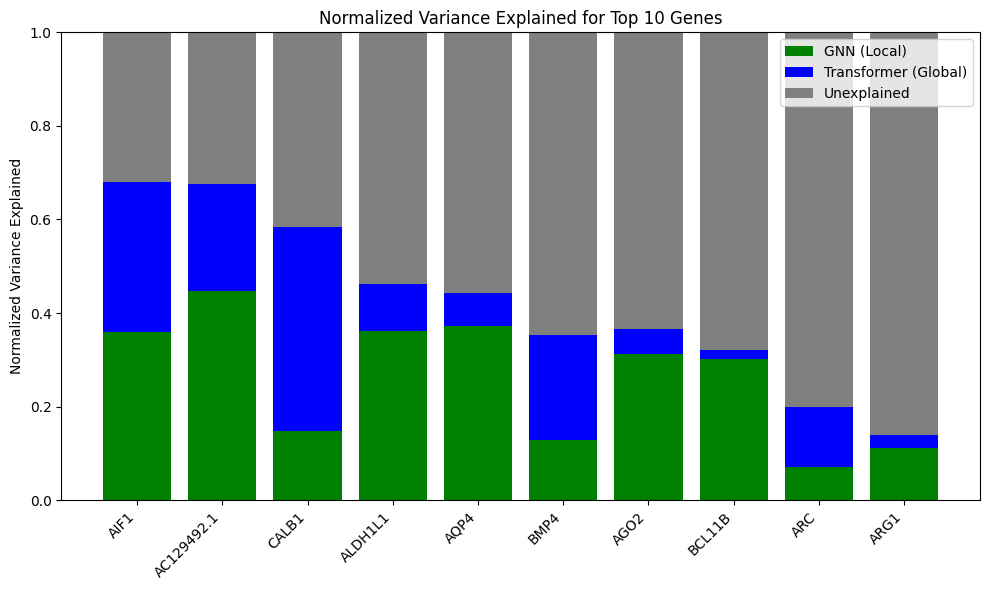

In [88]:
local_global_variance_composition(r2_gnn_mean, r2_transformer_mean, sub_adata_shh.var_names, n_genes=10)